In [77]:
# ══════════════════════════════ CELL 1 — engine ══════════════════════════════
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

# ─────────────────────────── registry ───────────────────────────
# Every indicator is a function (df, params) -> float Series of 1.0 / 0.0 / NaN
# 1.0 = ON, 0.0 = OFF, NaN = not enough history yet (warmup).
# To add a new one: write the function, slap @register("name") on it. Done.

INDICATORS = {}

def register(name):
    def deco(fn):
        INDICATORS[name] = fn
        return fn
    return deco

DEFAULT_PARAMS = dict(
    sma_specs={
        "sma100_buf5": dict(window=100, buffer=0.05),
        "sma150_buf5": dict(window=150, buffer=0.05),
        "sma200_buf5": dict(window=200, buffer=0.05),
        "sma250_buf5": dict(window=250, buffer=0.05),
    },
    vol_window=21,
    vol_max=0.40,
    ann_factor=252,
    ar_window=30,
)

def _make_sma(name):
    def fn(df, p):
        spec = p["sma_specs"][name]
        px = _close(df)
        ma = px.rolling(spec["window"]).mean()
        return _hysteresis(px, ma, spec["buffer"])
    fn.__name__ = f"_{name}"
    return fn

for _n in DEFAULT_PARAMS["sma_specs"]:
    register(_n)(_make_sma(_n))

# ─────────────────────────── helpers ───────────────────────────

def _close(df):
    return df["Close"].astype(float)

def _logret(df):
    return np.log(_close(df)).diff()

def _state(cond, valid):
    """boolean condition + validity mask -> 1/0/NaN float series"""
    s = cond.astype(float)
    s[~valid] = np.nan
    return s

def _hysteresis(price, ma, buffer):
    """
    Sticky band: flip ON only above ma*(1+buffer), flip OFF only below ma*(1-buffer),
    hold prior state inside the band. This is the 'buffer either direction' reading.
    If you'd rather have a hard one-sided threshold, swap the call for
    _state(price > ma * (1 + buffer), ma.notna()).
    """
    p, m = price.to_numpy(), ma.to_numpy()
    up, lo = m * (1 + buffer), m * (1 - buffer)
    out = np.full(len(p), np.nan)
    cur = np.nan
    for i in range(len(p)):
        if np.isnan(m[i]):
            continue
        if p[i] > up[i]:
            cur = 1.0
        elif p[i] < lo[i]:
            cur = 0.0
        elif np.isnan(cur):                      # first bar inside the band
            cur = 1.0 if p[i] >= m[i] else 0.0
        out[i] = cur
    return pd.Series(out, index=price.index)

# ─────────────────────────── indicators ───────────────────────────

@register("vol21")
def _vol(df, p):
    r = _logret(df)
    vol = r.rolling(p["vol_window"]).std(ddof=1) * np.sqrt(p["ann_factor"])
    return _state(vol < p["vol_max"], vol.notna())

@register("ar1_30")
def _ar1(df, p):
    r = _logret(df)
    lag = r.shift(1)
    w = p["ar_window"]
    beta = r.rolling(w).cov(lag) / lag.rolling(w).var()   # OLS slope, no intercept drift issue
    return _state(beta > 0, beta.notna())

# ─────────────────────────── core run ───────────────────────────

def compute_states(df, indicators, params=None):
    params = params or {}
    p = {**DEFAULT_PARAMS, **params}
    p["sma_specs"] = {**DEFAULT_PARAMS["sma_specs"], **params.get("sma_specs", {})}
    missing = [k for k in indicators if k not in INDICATORS]
    if missing:
        raise KeyError(f"unknown indicator(s) {missing}; available: {sorted(INDICATORS)}")
    return pd.DataFrame({k: INDICATORS[k](df, p) for k in indicators})

def build_flips(px, states, n):
    """px: Close series. states: DataFrame of 1/0. Returns full frame + flip table."""
    out = states.copy()
    out["score"] = states.sum(axis=1).astype(int)
    out["on"] = out["score"] >= n
    out["close"] = px.reindex(out.index)

    flip_mask = out["on"] != out["on"].shift(1)
    flip_mask.iloc[0] = False                     # first bar is the initial state, not a flip
    idx = out.index[flip_mask]

    rows = []
    marks = [out.index[0]] + list(idx) + [out.index[-1]]
    for i, d in enumerate(idx):
        prev_start = marks[i]
        held = out.loc[prev_start:d].iloc[:-1]
        rows.append({
            "date": d,
            "flip": "ON" if out.at[d, "on"] else "OFF",
            "close": round(out.at[d, "close"], 2),
            "score": f'{out.at[d, "score"]}/{len(states.columns)}',
            **{c: ("ON" if out.at[d, c] == 1 else "off") for c in states.columns},
            "prior_state": "ON" if not out.at[d, "on"] else "OFF",
            "prior_days": len(held),
            "prior_ret_%": round(100 * (out.at[d, "close"] / held["close"].iloc[0] - 1), 1),
        })
    flips = pd.DataFrame(rows)
    if not flips.empty:
        flips = flips.set_index("date")
    return out, flips

# ─────────────────────────── display ───────────────────────────

def plot_regime(ticker, out, flips, log_scale=True):
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(out.index, out["close"], color="0.15", lw=1.1, zorder=3)

    # light shading over ON stretches
    on = out["on"].to_numpy()
    start = None
    for i, v in enumerate(on):
        if v and start is None:
            start = out.index[i]
        if (not v or i == len(on) - 1) and start is not None:
            ax.axvspan(start, out.index[i], color="tab:green", alpha=0.07, zorder=0)
            start = None

    for d, row in flips.iterrows():
        ax.axvline(d, color="tab:green" if row["flip"] == "ON" else "tab:red",
                   lw=1.0, alpha=0.85, zorder=2)

    if log_scale:
        ax.set_yscale("log")
    ax.set_title(f"{ticker} — regime flips  ({out.index[0]:%Y-%m-%d} → {out.index[-1]:%Y-%m-%d})")
    ax.set_ylabel("price (adj)" + (" — log" if log_scale else ""))
    ax.grid(alpha=0.25)
    ax.legend(handles=[Line2D([], [], color="tab:green", label="flip ON"),
                       Line2D([], [], color="tab:red", label="flip OFF")], loc="upper left")
    plt.tight_layout()
    plt.show()

def run_regime(ticker, indicators, n, start=None, end=None,
               params=None, log_scale=True, show=True):
    raw = yf.download(ticker, period="max", auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError(f"no data for {ticker}")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    states = compute_states(raw, indicators, params).dropna()   # full history, then trim
    if start is not None:
        states = states[states.index >= pd.Timestamp(start)]
    if end is not None:
        states = states[states.index <= pd.Timestamp(end)]
    if states.empty:
        raise ValueError("window is empty after indicator warmup — try an earlier start")

    out, flips = build_flips(_close(raw), states, n)

    if show:
        pct_on = 100 * out["on"].mean()
        print(f"{ticker}  |  {', '.join(indicators)}  |  n = {n}")
        print(f"{out.index[0]:%Y-%m-%d} → {out.index[-1]:%Y-%m-%d}  |  "
              f"{len(out)} bars  |  {pct_on:.1f}% of days ON  |  {len(flips)} flips\n")
        display(flips if not flips.empty else "no flips in window")
        plot_regime(ticker, out, flips, log_scale)

    return out, flips

In [119]:
# ══════════════════════════════ CELL 1 — engine ══════════════════════════════
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

# ─────────────────────────── registry ───────────────────────────
# Every indicator is a function (df, params) -> float Series of 1.0 / 0.0 / NaN
# 1.0 = ON, 0.0 = OFF, NaN = not enough history yet (warmup).
# To add a new one: write the function, slap @register("name") on it. Done.

INDICATORS = {}

def register(name):
    def deco(fn):
        INDICATORS[name] = fn
        return fn
    return deco

DEFAULT_PARAMS = dict(
    sma_specs={
        "sma100_buf5": dict(window=100, buffer=0.05),
        "sma150_buf5": dict(window=150, buffer=0.05),
        "sma200_buf5": dict(window=200, buffer=0.05),
        "sma250_buf5": dict(window=250, buffer=0.05),
    },
    vol_window=21,
    vol_max=0.40,
    ann_factor=252,
    ar_window=30,
)

def _make_sma(name):
    def fn(df, p):
        spec = p["sma_specs"][name]
        px = _close(df)
        ma = px.rolling(spec["window"]).mean()
        return _hysteresis(px, ma, spec["buffer"])
    fn.__name__ = f"_{name}"
    return fn

for _n in DEFAULT_PARAMS["sma_specs"]:
    register(_n)(_make_sma(_n))

# ─────────────────────────── helpers ───────────────────────────

def _close(df):
    return df["Close"].astype(float)

def _logret(df):
    return np.log(_close(df)).diff()

def _state(cond, valid):
    """boolean condition + validity mask -> 1/0/NaN float series"""
    s = cond.astype(float)
    s[~valid] = np.nan
    return s

def _hysteresis(price, ma, buffer):
    """
    Sticky band: flip ON only above ma*(1+buffer), flip OFF only below ma*(1-buffer),
    hold prior state inside the band. This is the 'buffer either direction' reading.
    If you'd rather have a hard one-sided threshold, swap the call for
    _state(price > ma * (1 + buffer), ma.notna()).
    """
    p, m = price.to_numpy(), ma.to_numpy()
    up, lo = m * (1 + buffer), m * (1 - buffer)
    out = np.full(len(p), np.nan)
    cur = np.nan
    for i in range(len(p)):
        if np.isnan(m[i]):
            continue
        if p[i] > up[i]:
            cur = 1.0
        elif p[i] < lo[i]:
            cur = 0.0
        elif np.isnan(cur):                      # first bar inside the band
            cur = 1.0 if p[i] >= m[i] else 0.0
        out[i] = cur
    return pd.Series(out, index=price.index)

# ─────────────────────────── indicators ───────────────────────────

@register("vol21")
def _vol(df, p):
    r = _logret(df)
    vol = r.rolling(p["vol_window"]).std(ddof=1) * np.sqrt(p["ann_factor"])
    return _state(vol < p["vol_max"], vol.notna())

@register("ar1_30")
def _ar1(df, p):
    r = _logret(df)
    lag = r.shift(1)
    w = p["ar_window"]
    beta = r.rolling(w).cov(lag) / lag.rolling(w).var()   # OLS slope, no intercept drift issue
    return _state(beta > 0, beta.notna())

def stretch(df, p, key="sma250_buf5"):
    spec = p["sma_specs"][key]
    px = _close(df)
    return px / px.rolling(spec["window"]).mean() - 1

def exit_drop(s, buf_dn=0.05):
    """fraction price must fall from here to trip the exit"""
    return (1 - (1 - buf_dn) / (1 + s)).clip(lower=0.005)

def leverage_from_stretch(s, buf_dn=0.05, budget=0.5, tiers=(1, 2, 3)):
    """largest tier whose loss-to-exit stays inside the budget.
    (1-drop)^L is the compounding approximation — it reproduced your table
    well: drop=0.22 at L=3 gives -52% vs the -55% median you measured."""
    d = exit_drop(s, buf_dn)
    L = np.log(1 - budget) / np.log(1 - d)
    out = pd.Series(float(tiers[0]), index=s.index)
    for t in tiers:
        out[L >= t] = float(t)
    return out, d

# ─────────────────────────── core run ───────────────────────────

def compute_states(df, indicators, params=None):
    params = params or {}
    p = {**DEFAULT_PARAMS, **params}
    p["sma_specs"] = {**DEFAULT_PARAMS["sma_specs"], **params.get("sma_specs", {})}
    missing = [k for k in indicators if k not in INDICATORS]
    if missing:
        raise KeyError(f"unknown indicator(s) {missing}; available: {sorted(INDICATORS)}")
    return pd.DataFrame({k: INDICATORS[k](df, p) for k in indicators})

def build_flips(px, states, n):
    """px: Close series. states: DataFrame of 1/0. Returns full frame + flip table."""
    out = states.copy()
    out["score"] = states.sum(axis=1).astype(int)
    out["on"] = out["score"] >= n
    out["close"] = px.reindex(out.index)

    flip_mask = out["on"] != out["on"].shift(1)
    flip_mask.iloc[0] = False                     # first bar is the initial state, not a flip
    idx = out.index[flip_mask]

    rows = []
    marks = [out.index[0]] + list(idx) + [out.index[-1]]
    for i, d in enumerate(idx):
        prev_start = marks[i]
        held = out.loc[prev_start:d].iloc[:-1]
        rows.append({
            "date": d,
            "flip": "ON" if out.at[d, "on"] else "OFF",
            "close": round(out.at[d, "close"], 2),
            "score": f'{out.at[d, "score"]}/{len(states.columns)}',
            **{c: ("ON" if out.at[d, c] == 1 else "off") for c in states.columns},
            "prior_state": "ON" if not out.at[d, "on"] else "OFF",
            "prior_days": len(held),
            "prior_ret_%": round(100 * (out.at[d, "close"] / held["close"].iloc[0] - 1), 1),
        })
    flips = pd.DataFrame(rows)
    if not flips.empty:
        flips = flips.set_index("date")
    return out, flips

# ─────────────────────────── display ───────────────────────────

def plot_regime(ticker, out, flips, log_scale=True):
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(out.index, out["close"], color="0.15", lw=1.1, zorder=3)

    # light shading over ON stretches
    on = out["on"].to_numpy()
    start = None
    for i, v in enumerate(on):
        if v and start is None:
            start = out.index[i]
        if (not v or i == len(on) - 1) and start is not None:
            ax.axvspan(start, out.index[i], color="tab:green", alpha=0.07, zorder=0)
            start = None

    for d, row in flips.iterrows():
        ax.axvline(d, color="tab:green" if row["flip"] == "ON" else "tab:red",
                   lw=1.0, alpha=0.85, zorder=2)

    if log_scale:
        ax.set_yscale("log")
    ax.set_title(f"{ticker} — regime flips  ({out.index[0]:%Y-%m-%d} → {out.index[-1]:%Y-%m-%d})")
    ax.set_ylabel("price (adj)" + (" — log" if log_scale else ""))
    ax.grid(alpha=0.25)
    ax.legend(handles=[Line2D([], [], color="tab:green", label="flip ON"),
                       Line2D([], [], color="tab:red", label="flip OFF")], loc="upper left")
    plt.tight_layout()
    plt.show()

_PX_CACHE = {}

def load_px(ticker):
    """Full OHLC history, cached. Same shape run_regime uses internally."""
    if ticker not in _PX_CACHE:
        df = yf.download(ticker, period="max", auto_adjust=True, progress=False)
        if df.empty:
            raise ValueError(f"no data for {ticker}")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        _PX_CACHE[ticker] = df
    return _PX_CACHE[ticker]

def run_regime(ticker, indicators, n, start=None, end=None,
               params=None, log_scale=True, show=True):
    raw = load_px(ticker)
    if raw.empty:
        raise ValueError(f"no data for {ticker}")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    states = compute_states(raw, indicators, params).dropna()   # full history, then trim
    if start is not None:
        states = states[states.index >= pd.Timestamp(start)]
    if end is not None:
        states = states[states.index <= pd.Timestamp(end)]
    if states.empty:
        raise ValueError("window is empty after indicator warmup — try an earlier start")

    out, flips = build_flips(_close(raw), states, n)

    if show:
        pct_on = 100 * out["on"].mean()
        print(f"{ticker}  |  {', '.join(indicators)}  |  n = {n}")
        print(f"{out.index[0]:%Y-%m-%d} → {out.index[-1]:%Y-%m-%d}  |  "
              f"{len(out)} bars  |  {pct_on:.1f}% of days ON  |  {len(flips)} flips\n")
        display(flips if not flips.empty else "no flips in window")
        plot_regime(ticker, out, flips, log_scale)

    return out, flips

QLD  |  vol21, ar1_30  |  n = -1
2006-08-04 → 2026-07-27  |  5024 bars  |  100.0% of days ON  |  0 flips



'no flips in window'

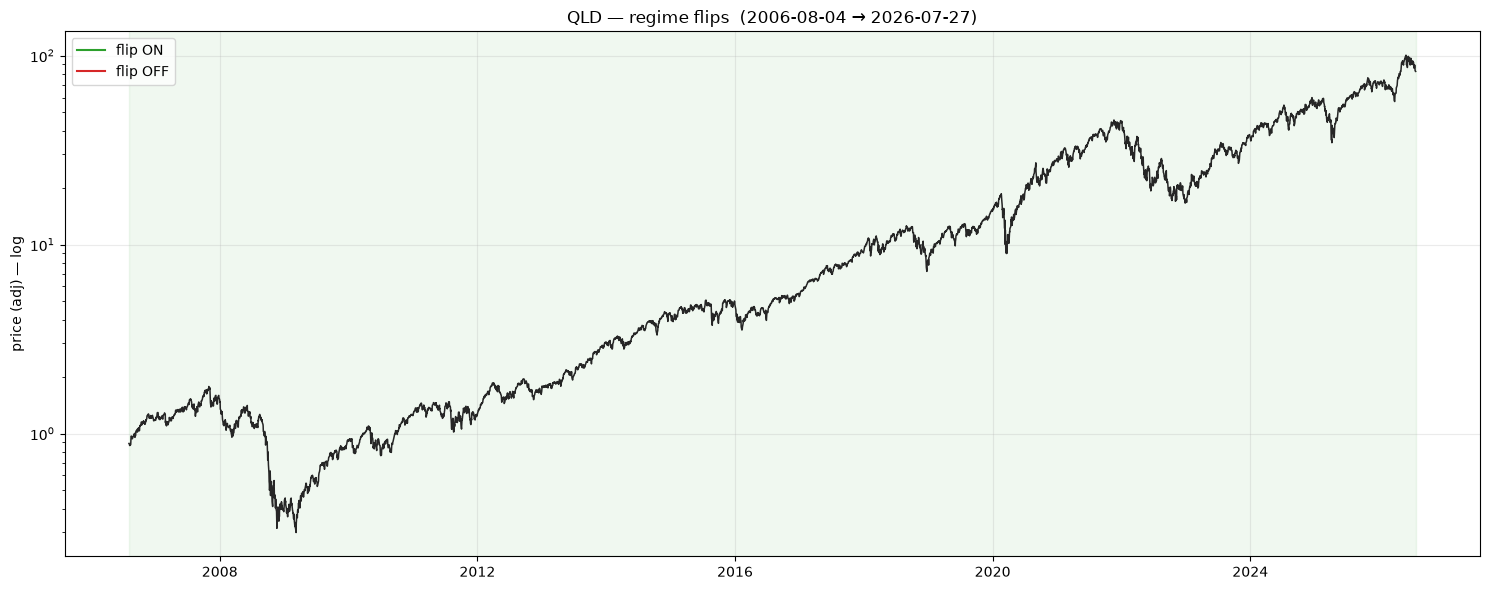

In [129]:
# ══════════════════════════════ CELL 2 — run ══════════════════════════════
TICKER     = "QLD"
INDICATOR_SET = ["vol21", "ar1_30"] # "sma250_buf5", "sma200_buf5", "sma100", "vol21", "ar1_30" default
N          = -1          # >= N indicators ON  →  hold; else flat
START      = None       # None = inception (first bar after warmup)
END        = None       # None = today
PARAMS     = {}         # e.g. {"sma_long": 250, "vol_max": 0.35}

out, flips = run_regime(TICKER, INDICATOR_SET, N,
                        start=START, end=END, params=PARAMS, log_scale=True)

In [121]:
def sim(out, raw, lev, er=0.0095, rf=0.04):
    r = _close(raw).pct_change().reindex(out.index)
    L = lev.reindex(out.index).shift(1).fillna(0)
    L = L.where(out["on"].shift(1).fillna(False), 0.0)     # flat when OFF
    cost = (er + np.maximum(L - 1, 0) * rf) / 252          # ER + financing on borrowed part
    return (1 + L * r - cost).cumprod()

def stats(eq):
    r = eq.pct_change().dropna()
    yrs = len(r) / 252
    dd = (eq / eq.cummax() - 1).min()
    dn = r[r < 0].std() * np.sqrt(252)
    return dict(CAGR=round(100 * ((eq.iloc[-1]) ** (1 / yrs) - 1), 1),
                maxDD=round(100 * dd, 1),
                Sortino=round((eq.iloc[-1] ** (1 / yrs) - 1) / dn, 2))
raw = load_px(TICKER)
s = stretch(raw, merge_params(PARAMS)).reindex(out.index)
sched, _ = leverage_from_stretch(s)

res = {f"static {L}x": stats(sim(out, raw, pd.Series(float(L), index=out.index)))
       for L in (1, 2, 3)}
res["stretch-scheduled"] = stats(sim(out, raw, sched))
display(pd.DataFrame(res).T)
print(sched[out["on"]].value_counts(normalize=True).round(2))

,CAGR,maxDD,Sortino
static 1x,8.0,-36.6,0.58
static 2x,11.0,-63.2,0.40
static 3x,10.7,-82.3,0.26
stretch-scheduled,16.6,-65.3,0.43


3.0    0.89
2.0    0.11
1.0    0.01
Name: proportion, dtype: float64


In [122]:
# CONTROL 1 — is it timing, or just the average leverage?
avg = sched[out["on"]].mean()
res2 = {f"static {avg:.2f}x": stats(sim(out, raw, pd.Series(avg, index=out.index)))}

# CONTROL 2 — inverted schedule. Should be clearly worse if the signal is real.
res2["inverted"] = stats(sim(out, raw, sched.map({1.0: 3.0, 2.0: 2.0, 3.0: 1.0})))

# CONTROL 3 — same leverage distribution, shuffled in time.
rng = np.random.default_rng(0)
sh = [stats(sim(out, raw, pd.Series(rng.permutation(sched.values), index=out.index)))["CAGR"]
      for _ in range(50)]
res2["shuffled (mean)"] = {"CAGR": round(np.mean(sh), 1), "maxDD": None,
                           "Sortino": round(np.percentile(sh, 95), 1)}   # 95th pct in Sortino col
display(pd.DataFrame(res2).T)


,CAGR,maxDD,Sortino
static 2.88x,10.9,-80.5,0.27
inverted,3.0,-70.4,0.15
shuffled (mean),10.4,NaN,12.40


In [123]:
def block_shuffle(x, blk, rng):
    n = len(x); v = x.values
    starts = rng.integers(0, n - blk, size=n // blk + 1)
    return pd.Series(np.concatenate([v[s:s+blk] for s in starts])[:n], index=x.index)

rng = np.random.default_rng(1)
bs = [stats(sim(out, raw, block_shuffle(sched, 60, rng)))["CAGR"] for _ in range(200)]
print(f"block-shuffled: mean {np.mean(bs):.1f}  p95 {np.percentile(bs,95):.1f}  "
      f"max {np.max(bs):.1f}  |  actual 16.8  |  p = {np.mean(np.array(bs) >= 16.8):.3f}")

block-shuffled: mean 10.7  p95 12.3  max 14.5  |  actual 16.8  |  p = 0.000


In [124]:
for a, z in [("2000-01-01","2010-12-31"), ("2011-01-01","2026-07-31")]:
    m = (out.index >= a) & (out.index <= z)
    e_s, e_3 = sim(out[m], raw, sched[m]), sim(out[m], raw, pd.Series(3.0, index=out.index[m]))
    e_1 = sim(out[m], raw, pd.Series(1.0, index=out.index[m]))
    print(a[:4], "sched", stats(e_s), "| 3x", stats(e_3), "| 1x", stats(e_1))

2000 sched {'CAGR': np.float64(7.0), 'maxDD': np.float64(-61.0), 'Sortino': np.float64(0.18)} | 3x {'CAGR': np.float64(-1.9), 'maxDD': np.float64(-82.3), 'Sortino': np.float64(-0.05)} | 1x {'CAGR': np.float64(3.7), 'maxDD': np.float64(-36.6), 'Sortino': np.float64(0.26)}
2011 sched {'CAGR': np.float64(23.4), 'maxDD': np.float64(-65.3), 'Sortino': np.float64(0.6)} | 3x {'CAGR': np.float64(20.1), 'maxDD': np.float64(-66.3), 'Sortino': np.float64(0.49)} | 1x {'CAGR': np.float64(11.0), 'maxDD': np.float64(-27.8), 'Sortino': np.float64(0.82)}


In [118]:
def rearm_schedule(on, off_min=20, hold=120, base=2.0, boost=3.0):
    """3x for `hold` bars after re-entry, but only if the OFF spell ran >= off_min."""
    v = on.to_numpy()
    lev = np.full(len(v), base)
    run = 0
    left = 0
    for i in range(len(v)):
        if not v[i]:
            run += 1
            left = 0
        else:
            if i > 0 and not v[i-1] and run >= off_min:
                left = hold
            run = 0
            if left > 0:
                lev[i] = boost
                left -= 1
    return pd.Series(lev, index=on.index)

rearm = rearm_schedule(out["on"])
res3 = {"stretch-sched": stats(sim(out, raw, sched)),
        "rearm T20D90":  stats(sim(out, raw, rearm)),
        "static 2x":     stats(sim(out, raw, pd.Series(2.0, index=out.index)))}
display(pd.DataFrame(res3).T)

for a, z in [("2000-01-01","2010-12-31"), ("2011-01-01","2026-07-31")]:
    m = (out.index >= a) & (out.index <= z)
    print(a[:4], "rearm", stats(sim(out[m], raw, rearm[m])),
                 "| stretch", stats(sim(out[m], raw, sched[m])))

print(f"\n3x days: rearm {100*(rearm==3).mean():.1f}%  stretch {100*(sched==3).mean():.1f}%")

,CAGR,maxDD,Sortino
stretch-sched,10.0,-45.6,0.43
rearm T20D90,13.7,-65.1,0.44
static 2x,11.0,-63.2,0.40


2000 rearm {'CAGR': np.float64(5.1), 'maxDD': np.float64(-65.1), 'Sortino': np.float64(0.17)} | stretch {'CAGR': np.float64(9.9), 'maxDD': np.float64(-39.1), 'Sortino': np.float64(0.46)}
2011 rearm {'CAGR': np.float64(19.8), 'maxDD': np.float64(-51.6), 'Sortino': np.float64(0.64)} | stretch {'CAGR': np.float64(9.9), 'maxDD': np.float64(-45.6), 'Sortino': np.float64(0.41)}

3x days: rearm 19.3%  stretch 30.3%
